## Imports + Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
master_df = pd.read_csv(os.path.join(base_dir, 'data', 'processed', 'master_df.csv'), index_col=0)

print("✅ Libraries loaded")
print(f"✅ master_df loaded — {master_df.shape}")

✅ Libraries loaded
✅ master_df loaded — (3, 19)


## Unit Economics Data

In [2]:
# All figures sourced from industry benchmarks + master_df where available
unit_econ = {
    'HVLP': {
        'CAC':           75,      # low — mass market, digital ads
        'Monthly_Rev':   22,      # blended ARPU (Planet Fitness ~$22/mo)
        'Churn_Monthly': 0.035,   # 3.5% monthly churn
        'Gross_Margin':  0.394,   # 39.4% from master_df
        'Payback_Mos':   4,       # CAC / monthly contribution
    },
    'Boutique': {
        'CAC':           320,     # higher — local marketing, referrals
        'Monthly_Rev':   185,     # $150-$220/mo memberships
        'Churn_Monthly': 0.065,   # 6.5% monthly churn (higher price sensitivity)
        'Gross_Margin':  0.35,    # 35% estimated
        'Payback_Mos':   7,
    },
    'Digital': {
        'CAC':           95,      # paid social, app store
        'Monthly_Rev':   18,      # ~$15-$20/mo subscriptions
        'Churn_Monthly': 0.085,   # 8.5% monthly churn (lowest stickiness)
        'Gross_Margin':  0.08,    # 8% — Peloton/Mirror hardware drag
        'Payback_Mos':   18,
    },
}

categories = list(unit_econ.keys())

# Derive LTV = (Monthly_Rev * Gross_Margin) / Churn_Monthly
for cat, d in unit_econ.items():
    d['LTV'] = (d['Monthly_Rev'] * d['Gross_Margin']) / d['Churn_Monthly']
    d['LTV_CAC'] = round(d['LTV'] / d['CAC'], 2)

for cat, d in unit_econ.items():
    print(f"{cat:<10}  CAC: ${d['CAC']}  |  LTV: ${d['LTV']:,.0f}  |  LTV:CAC: {d['LTV_CAC']}x  |  Payback: {d['Payback_Mos']} months")

HVLP        CAC: $75  |  LTV: $248  |  LTV:CAC: 3.3x  |  Payback: 4 months
Boutique    CAC: $320  |  LTV: $996  |  LTV:CAC: 3.11x  |  Payback: 7 months
Digital     CAC: $95  |  LTV: $17  |  LTV:CAC: 0.18x  |  Payback: 18 months


## LTC vs CAC Bar Chart

/var/folders/tq/h_vw_lvn17g5f24p0db38fww0000gn/T/ipykernel_57462/3029965877.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, color='white', fontsize=11)
/var/folders/tq/h_vw_lvn17g5f24p0db38fww0000gn/T/ipykernel_57462/3029965877.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, color='white', fontsize=11)
/var/folders/tq/h_vw_lvn17g5f24p0db38fww0000gn/T/ipykernel_57462/3029965877.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, color='white', fontsize=11)


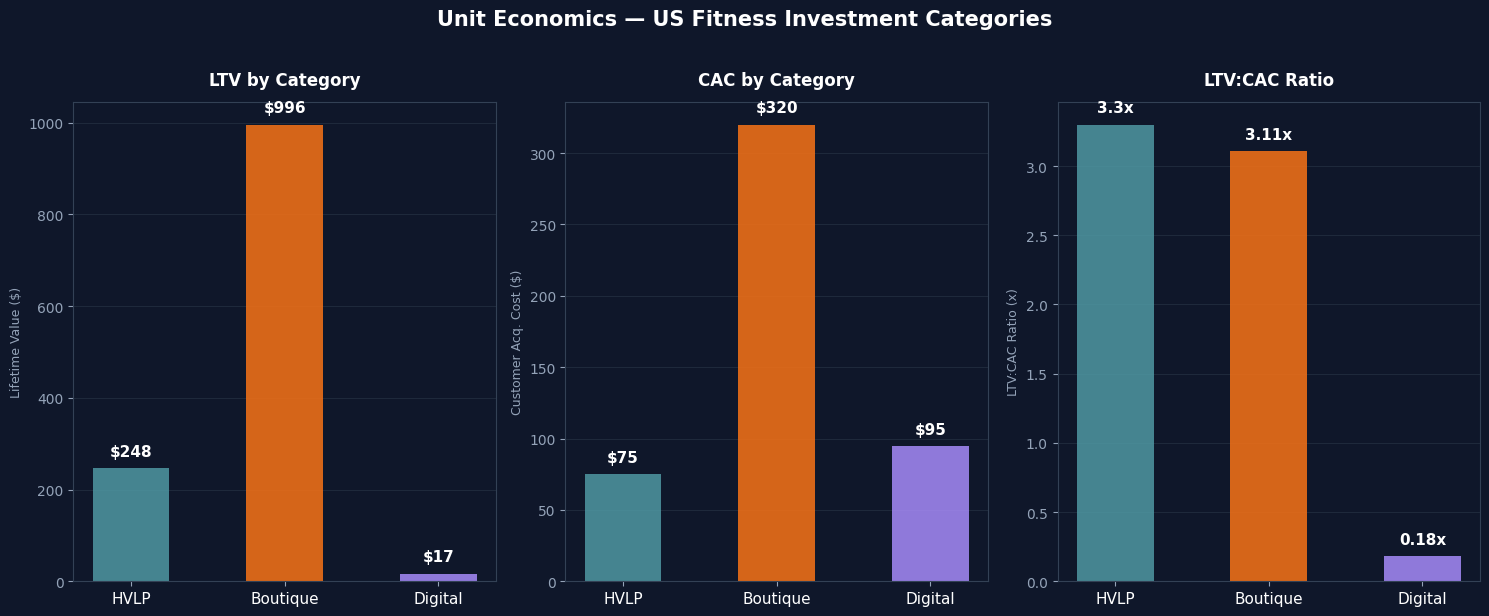

✅ Unit economics chart saved → output/unit_economics_bars.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor('#0f172a')

colors = {'HVLP': '#4f98a3', 'Boutique': '#f97316', 'Digital': '#a78bfa'}
metrics = [
    ('LTV',     'Lifetime Value ($)',        'LTV by Category'),
    ('CAC',     'Customer Acq. Cost ($)',     'CAC by Category'),
    ('LTV_CAC', 'LTV:CAC Ratio (x)',          'LTV:CAC Ratio'),
]

for ax, (key, ylabel, title) in zip(axes, metrics):
    ax.set_facecolor('#0f172a')
    vals = [unit_econ[c][key] for c in categories]
    bars = ax.bar(categories, vals,
                  color=[colors[c] for c in categories],
                  width=0.5, alpha=0.85, edgecolor='none')

    for bar, val in zip(bars, vals):
        label = f'${val:,.0f}' if key != 'LTV_CAC' else f'{val}x'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                label, ha='center', va='bottom',
                color='white', fontsize=11, fontweight='bold')

    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=12)
    ax.set_ylabel(ylabel, color='#94a3b8', fontsize=9)
    ax.set_facecolor('#0f172a')
    ax.tick_params(colors='#94a3b8')
    ax.set_xticklabels(categories, color='white', fontsize=11)
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')
    ax.yaxis.grid(True, color='#1e293b', linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle('Unit Economics — US Fitness Investment Categories',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'unit_economics_bars.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Unit economics chart saved → output/unit_economics_bars.png")